# Soft X-Ray Signal Analysis

This notebook demonstrates the VEST SXR workflow using the `soft_x_rays` OMAS IDS and `vaft.plot` helpers. The sequence follows the usual diagnostic reading order: line-of-sight geometry, representative time trace, spectrogram, and chord-time pattern.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from vaft.machine_mapping.soft_x_rays import soft_x_rays_from_digitizer_csv
# These composite renderers keep their legacy options during the
# vaft.plot compatibility window; import them from their module.
from vaft.plot.soft_x_rays import (
    plot_soft_x_ray_los,
    plot_soft_x_ray_signal,
    plot_soft_x_ray_spectrogram,
    plot_soft_x_ray_pattern,
    plot_soft_x_ray_overview,
)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 200

## 1. Build a Soft X-Ray ODS

The example below prefers the VEST SXR tutorial raw data if it is present, and otherwise falls back to the packaged `vaft` sample. The resulting ODS contains both brightness traces and static line-of-sight metadata.

In [ ]:
shot = 45538
daq_label = 22577

vest_raw = Path("data/raw")  # optional checkout-relative VEST SXR archive
plasma_file = vest_raw / f"digitizer_{daq_label}_{shot}.csv"

if plasma_file.exists():
    ods = soft_x_rays_from_digitizer_csv(shot, daq_label, digitizer_file=plasma_file)
else:
    shot = 45531
    ods = soft_x_rays_from_digitizer_csv(shot, daq_label)

print(f"shot={shot}, daq_label={daq_label}")
print(f"channels={len(ods['soft_x_rays.channel'])}, samples={len(ods['soft_x_rays.time'])}")
print(ods['soft_x_rays.ids_properties.source'])

shot=45531, daq_label=22577
channels=64, samples=48828
/Users/yun/git/vaft/vaft/data/legacy/digitizer_22577_45531.csv


## 2. Line-of-Sight Geometry

This plot uses `soft_x_rays.channel[:].line_of_sight` and separates the array groups by color. The packaged geometry table carries the toroidal angle `phi`, so the plotted section can be tied back to the 12 o’clock / 4 o’clock SXR locations.

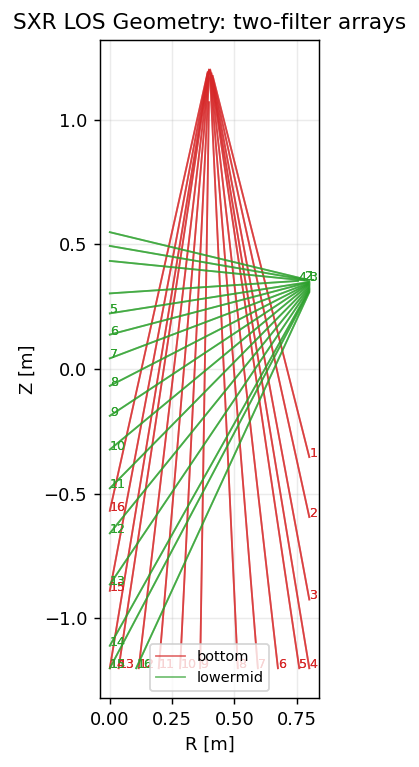

In [ ]:
plot_soft_x_ray_los(
    ods,
    arrays=["lowermid", "bottom"],
    show_channel_labels=True,
    title="SXR LOS Geometry: two-filter arrays",
);

## 3. Representative Signal

The time trace is read from `brightness.data`. These digitizer values are stored as a brightness proxy unless a calibrated `brightness_scale` is supplied during mapping.

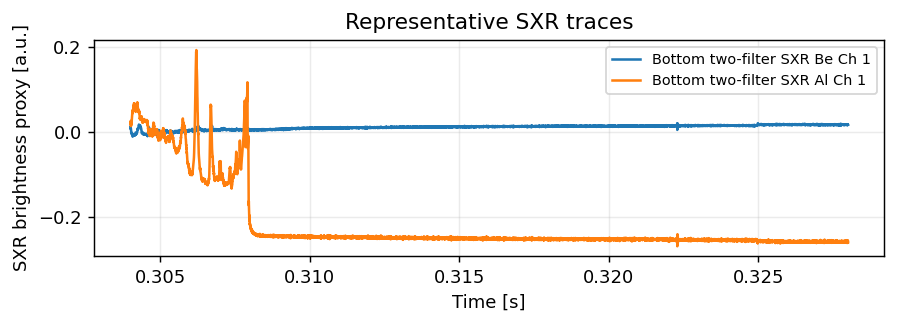

In [ ]:
time_range = (0.304, 0.328)
baseline_range = (0.304, 0.306)
representative_channels = [0, 16]  # lowermid ch 1 and bottom ch 1 for DAQ 22577

plot_soft_x_ray_signal(
    ods,
    channels=representative_channels,
    time_range=time_range,
    baseline_range=baseline_range,
    ylabel="SXR brightness proxy [a.u.]",
    title="Representative SXR traces",
);

## 4. Spectrogram

The spectrogram helper infers the sampling rate from the ODS time base. Use a shorter `nperseg` for better time localization near rapidly evolving internal MHD activity.

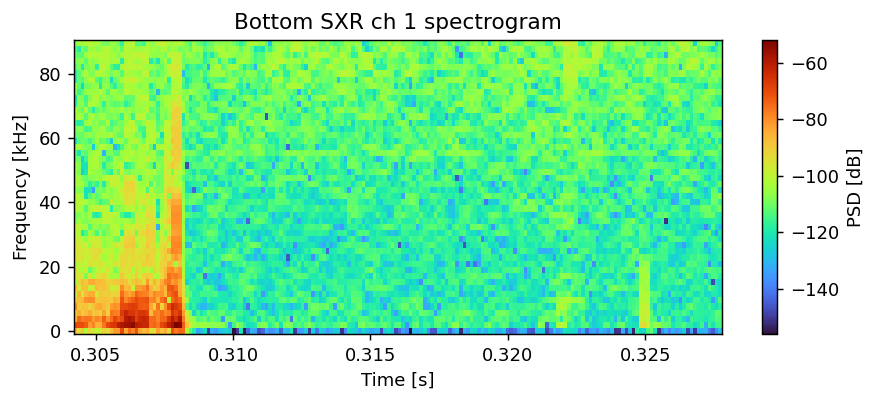

In [ ]:
plot_soft_x_ray_spectrogram(
    ods,
    channel=16,
    time_range=time_range,
    baseline_range=baseline_range,
    nperseg=512,
    noverlap=384,
    max_frequency=90_000,
    title="Bottom SXR ch 1 spectrogram",
);

## 5. SXR Chord-Time Pattern

This heatmap arranges a channel block as chord number versus time. It is useful for seeing radial/poloidal pattern motion before moving to filtered mode analysis.

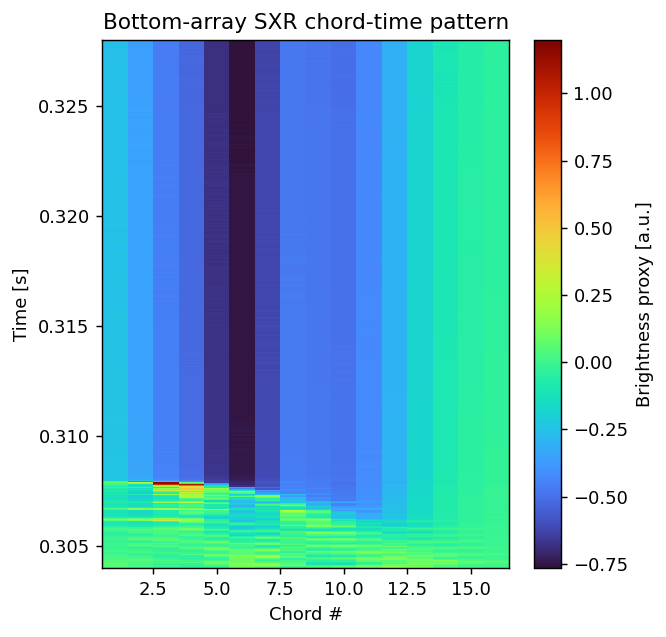

In [ ]:
bottom_channels = list(range(16, 32))

plot_soft_x_ray_pattern(
    ods,
    channels=bottom_channels,
    time_range=time_range,
    baseline_range=baseline_range,
    orientation="time_vertical",
    title="Bottom-array SXR chord-time pattern",
);

## 6. Compact Overview

The same helpers can be combined into a compact four-panel overview for quick shot screening.

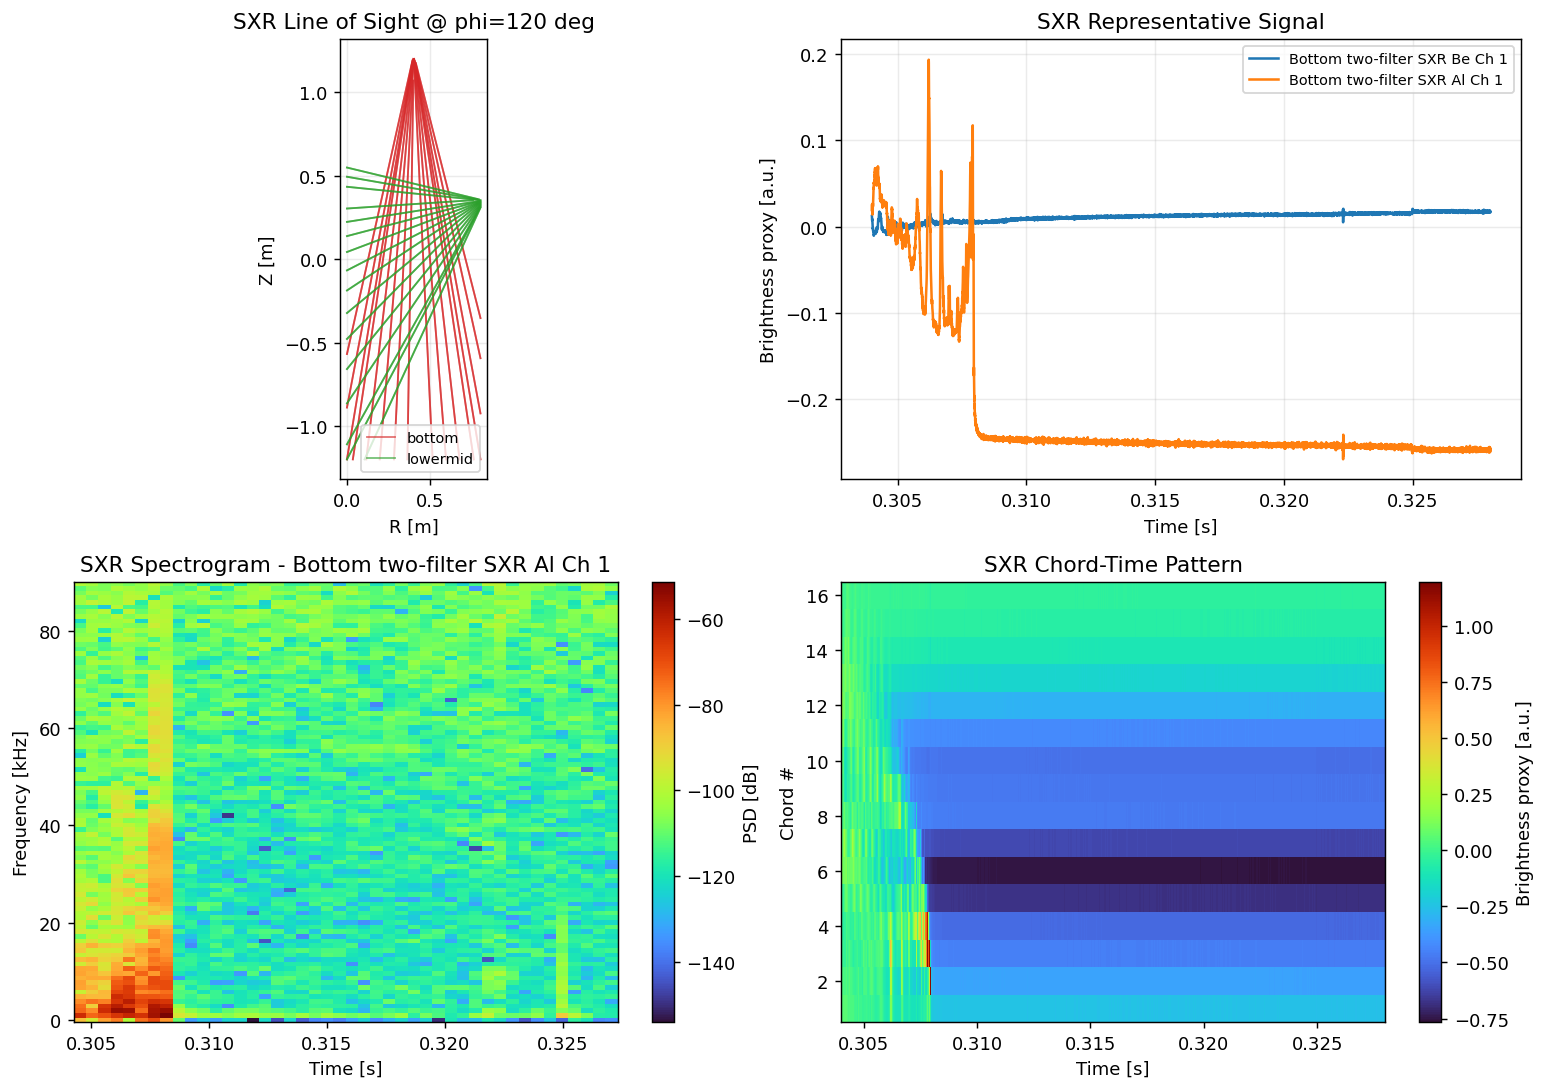

In [ ]:
plot_soft_x_ray_overview(
    ods,
    los_arrays=["lowermid", "bottom"],
    signal_channels=representative_channels,
    spectrogram_channel=16,
    pattern_channels=bottom_channels,
    time_range=time_range,
    baseline_range=baseline_range,
);

## 7. Fluctuation Processing with `vaft.process.soft_x_rays`

The sections below use the SXR analysis routines ported from the validated VEST SXR
Viewer (v5; see the 2026 VEST SXR thesis presentation for the physics validation):
band-decomposed chord maps, optional vacuum-shot PF-noise subtraction, two-filter
electron temperature, and a two-point toroidal mode-number estimate.

All routines take plain `(time, data)` arrays in seconds/Hz. In the 455xx campaign
both digitizers sample at $125\,\mathrm{MHz}/128 = 976{,}562.5$ Hz from the 285 ms
trigger, so the 4 o'clock and 12 o'clock systems share one timebase.

In [ ]:
import os

from vaft.machine_mapping.utils import get_path
from vaft.plot import render_image_2d, render_line_series
from vaft.plot.models import Image2D, LineSeries, Series
from vaft.process.soft_x_rays import (
    hilbert_instantaneous_phase,
    load_te_ratio_calibration,
    rank_toroidal_mode_numbers,
    sxr_band_signals,
    sxr_baseline_correction,
    sxr_electron_temperature,
    sxr_subtract_vacuum_reference,
    sxr_te_pairs_from_ods,
)

output_dir = Path(os.environ.get("VAFT_DOCS_OUTPUT_DIR", "notebooks/outputs/docs"))
output_dir.mkdir(parents=True, exist_ok=True)

sxr_time = np.asarray(ods["soft_x_rays.time"]).ravel()
sxr_data = np.vstack([
    np.asarray(ods[f"soft_x_rays.channel.{i}.brightness.data"]).ravel()
    for i in range(len(ods["soft_x_rays.channel"]))
])
sample_rate = 1.0 / np.median(np.diff(sxr_time))

analysis_window = (0.295, 0.309)   # plasma interval used by the validated viewer
baseline_start = 0.3331            # quiet tail after the plasma
print(f"{sxr_data.shape[0]} channels x {sxr_data.shape[1]} samples at {sample_rate:,.0f} Hz")

64 channels x 48828 samples at 976,562 Hz


### 7.1 Band-decomposed chord maps

`sxr_band_signals` runs baseline correction → time windowing → zero-phase Butterworth
band-pass into **caller-named bands**. The bands below are the viewer's validated
defaults for this campaign; they are arguments, not library constants.

The chord-time maps use the public ad-hoc renderer body `render_image_2d`; a dead or
saturated channel can be zeroed in the band maps (while staying visible in raw) via
`dead_channels=`.

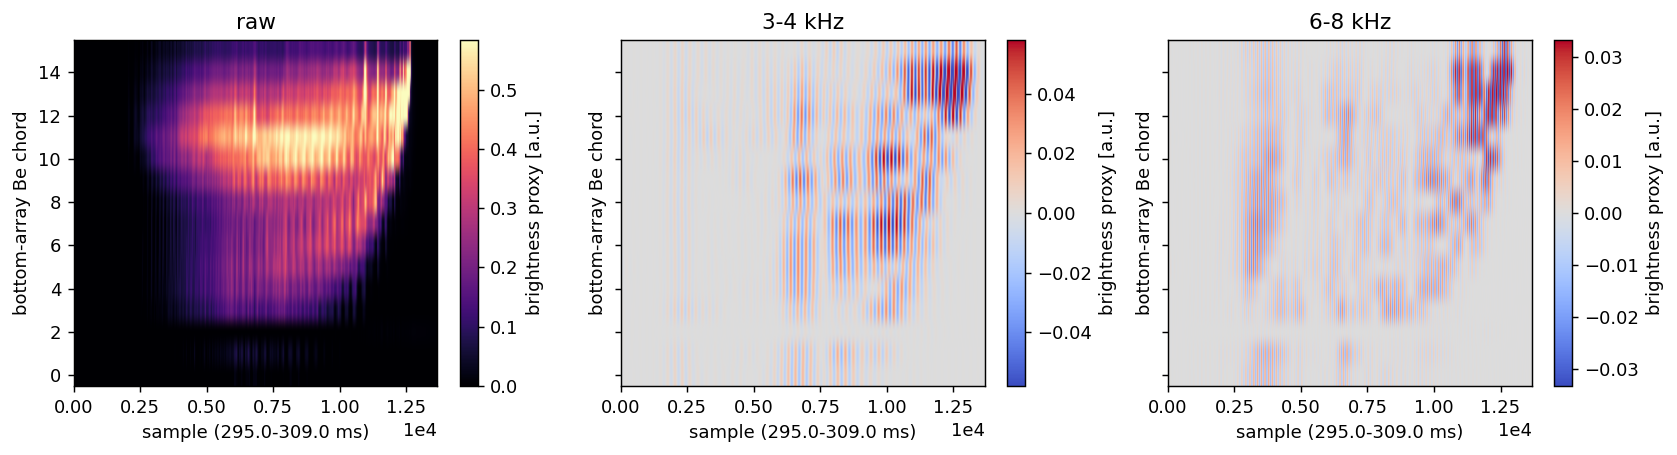

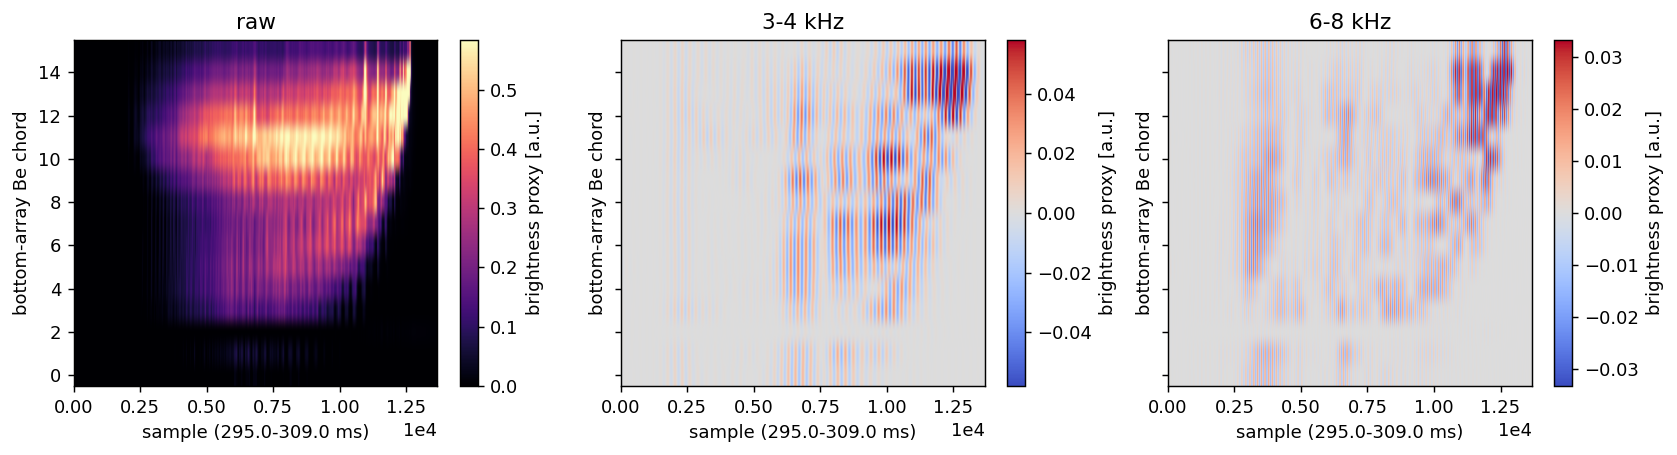

In [ ]:
bottom_be = list(range(0, 16))     # ODS channels: bottom-array Be chords

band_result = sxr_band_signals(
    sxr_time,
    sxr_data,
    baseline_start=baseline_start,
    bands={"3-4 kHz": (3.0e3, 4.0e3), "6-8 kHz": (6.0e3, 8.0e3)},
    fs=sample_rate,
    time_range=analysis_window,
    channels=bottom_be,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
panels = [("raw", band_result.raw, "magma")] + [
    (name, values, "coolwarm") for name, values in band_result.bands.items()
]
for axis, (name, values, cmap) in zip(axes, panels):
    limit = float(np.percentile(np.abs(values), 99))
    render_image_2d(
        Image2D(
            values=values,
            value_label="brightness proxy [a.u.]",
            x_label=f"sample ({band_result.time[0]*1e3:.1f}-{band_result.time[-1]*1e3:.1f} ms)",
            y_label="bottom-array Be chord",
            title=name,
            cmap=cmap,
            origin="lower",
            aspect_equal=False,
            vmin=(0.0 if name == "raw" else -limit),
            vmax=limit,
        ),
        ax=axis,
    )
fig.tight_layout()
fig.savefig(output_dir / "sxr_band_chord_maps.png", dpi=200, bbox_inches="tight")
fig

### 7.2 Optional: vacuum-shot PF-noise subtraction

PF coil ramps induce pickup that appears identically in a vacuum shot.
`sxr_subtract_vacuum_reference` low-passes the vacuum record and subtracts it channel
by channel. This is a **standalone optional pre-step**: no other routine applies it,
so the main path above analysed exactly the data it was given. To use it, run the
pre-step explicitly and pass the corrected matrix onward with `baseline_start=None`.

This demo needs the (unpackaged) vacuum record `digitizer_22577_45540.csv`. Point
`VAFT_SXR_REFERENCE_DIR` at a directory containing it; otherwise the cell reports
itself skipped.

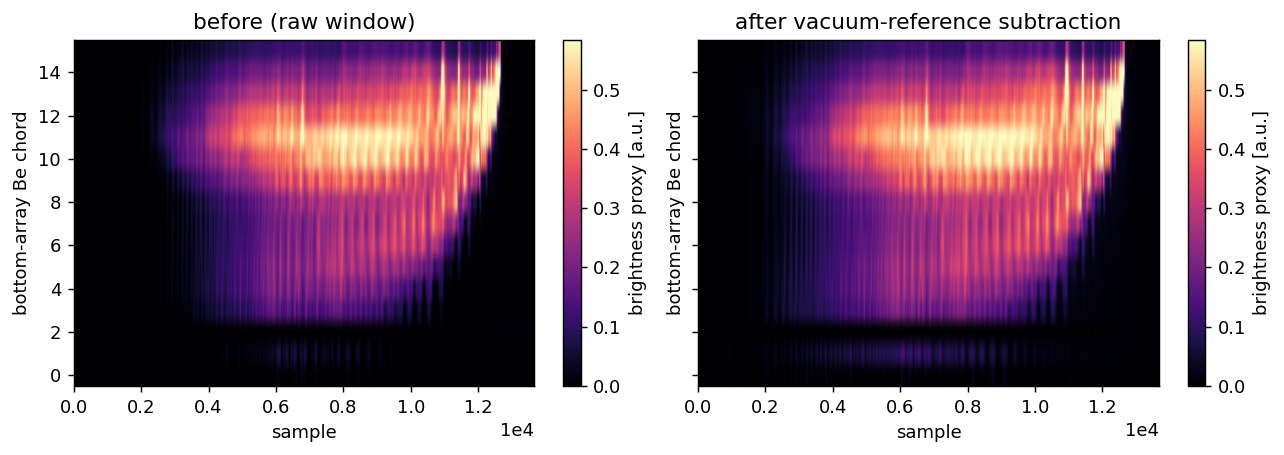

In [ ]:
reference_dir = os.environ.get("VAFT_SXR_REFERENCE_DIR", "")
reference_file = Path(reference_dir) / "digitizer_22577_45540.csv" if reference_dir else None

if reference_file is not None and reference_file.is_file():
    reference_ods = soft_x_rays_from_digitizer_csv(45540, 22577, digitizer_file=reference_file)
    reference_data = np.vstack([
        np.asarray(reference_ods[f"soft_x_rays.channel.{i}.brightness.data"]).ravel()
        for i in range(len(reference_ods["soft_x_rays.channel"]))
    ])

    plasma_base = sxr_baseline_correction(sxr_time, sxr_data, baseline_start)
    vacuum_base = sxr_baseline_correction(sxr_time, reference_data, baseline_start)
    corrected = sxr_subtract_vacuum_reference(
        plasma_base, vacuum_base, cutoff=3.0e3, fs=sample_rate
    )
    corrected_bands = sxr_band_signals(
        sxr_time[: corrected.shape[1]], corrected,
        baseline_start=None,                      # already corrected above
        bands={"3-4 kHz": (3.0e3, 4.0e3)},
        fs=sample_rate, time_range=analysis_window, channels=bottom_be,
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
    for axis, (name, values) in zip(
        axes,
        (("before (raw window)", band_result.raw),
         ("after vacuum-reference subtraction", corrected_bands.raw)),
    ):
        render_image_2d(
            Image2D(values=values, value_label="brightness proxy [a.u.]",
                    x_label="sample", y_label="bottom-array Be chord",
                    title=name, cmap="magma", origin="lower", aspect_equal=False,
                    vmin=0.0, vmax=float(np.percentile(band_result.raw, 99))),
            ax=axis,
        )
    fig.tight_layout()
    fig.savefig(output_dir / "sxr_vacuum_reference.png", dpi=200, bbox_inches="tight")
else:
    print("Skipped: set VAFT_SXR_REFERENCE_DIR to a directory holding "
          "digitizer_22577_45540.csv to run the optional PF-noise subtraction demo.")

### 7.3 Two-filter electron temperature

Each two-filter chord is viewed through beryllium and aluminium foils whose
transmission depends differently on photon energy, so the Be/Al signal ratio is a
monotonic function of $T_e$ for a near-Maxwellian plasma. The packaged calibration
table (`vaft/data/legacy/sxr_te_ratio_be_al.csv`, from the validated viewer) inverts
that ratio.

`sxr_te_pairs_from_ods` pairs Be and Al channels **by physical chord** from the
channel identifiers, absorbing any per-block wiring reversal. Samples where the
conditioned Al signal sits at or below `al_threshold` carry too little flux for a
meaningful ratio and come back as NaN. The `al_gain=1.07` default is the validated
relative-sensitivity correction of the Al channels.

16 Be/Al pairs; central-pair median Te = 27.5 eV; valid fraction = 66%


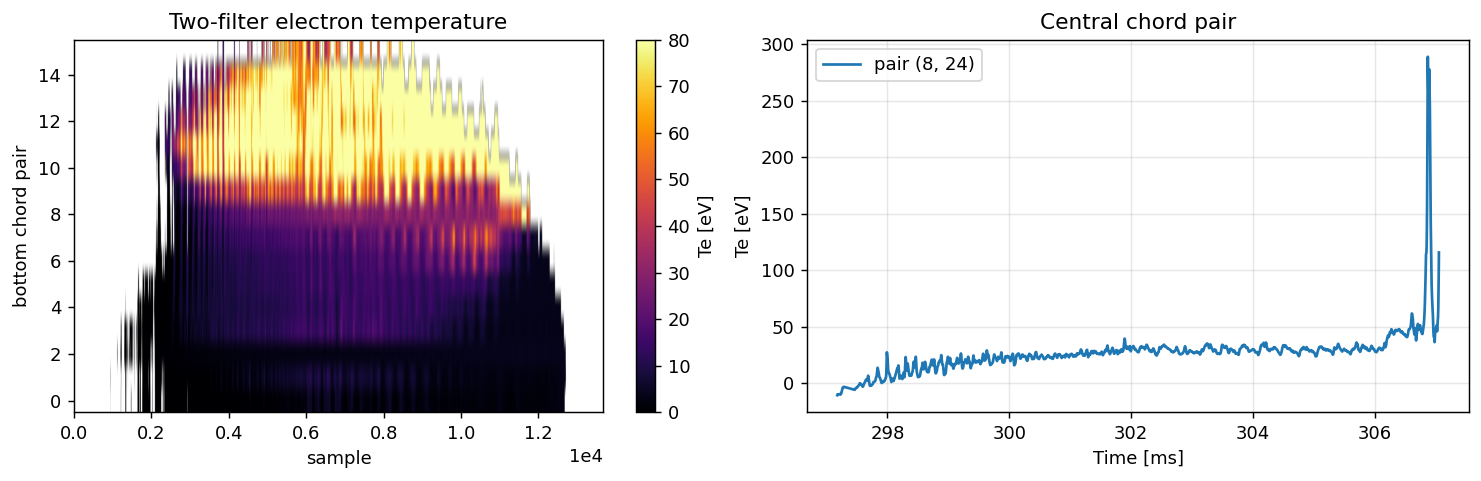

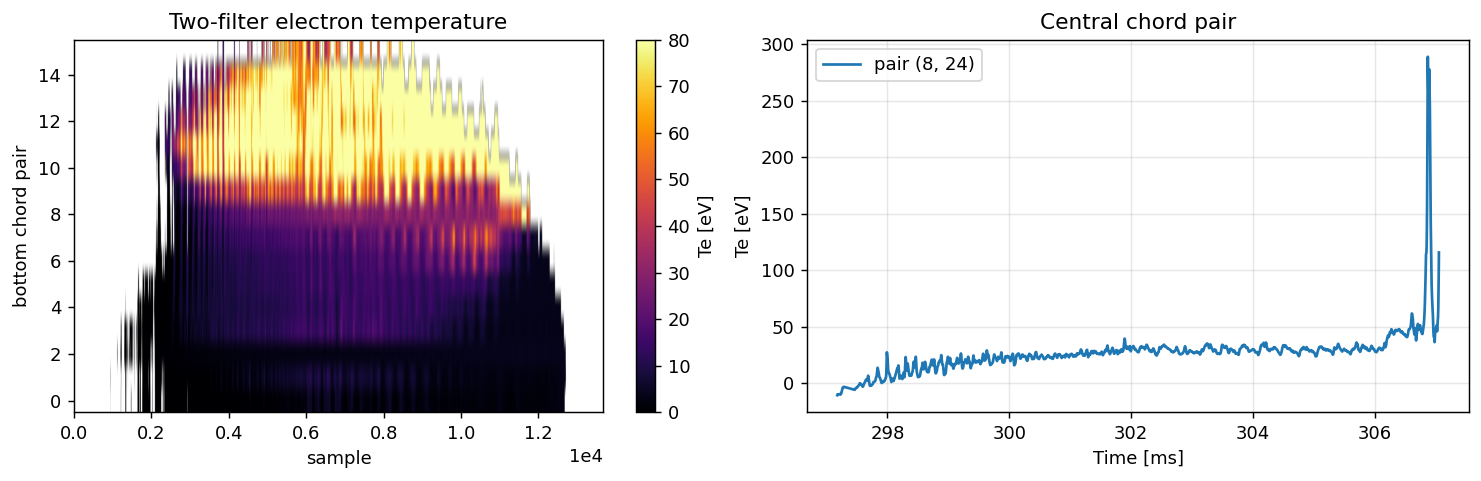

In [ ]:
calibration, cal_te, cal_ratio = load_te_ratio_calibration()
pairs = sxr_te_pairs_from_ods(ods, "bottom")

te_result = sxr_electron_temperature(
    sxr_time, sxr_data, pairs,
    calibration=calibration,
    baseline_start=baseline_start,
    fs=sample_rate,
    time_range=analysis_window,
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
render_image_2d(
    Image2D(values=te_result.te, value_label="Te [eV]",
            x_label="sample", y_label="bottom chord pair",
            title="Two-filter electron temperature", cmap="inferno",
            origin="lower", aspect_equal=False,
            # The viewer's display convention: clamp to the physically
            # expected range; near-threshold Al chords extrapolate wildly.
            vmin=0.0, vmax=80.0),
    ax=axes[0],
)
central = len(pairs) // 2
valid = np.isfinite(te_result.te[central])
render_line_series(
    LineSeries(
        series=(Series(x=te_result.time[valid] * 1e3, y=te_result.te[central][valid],
                       label=f"pair {te_result.pairs[central]}"),),
        x_label="Time", x_unit="ms", y_label="Te", y_unit="eV",
        title="Central chord pair",
    ),
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(output_dir / "sxr_electron_temperature.png", dpi=200, bbox_inches="tight")
print(f"{len(pairs)} Be/Al pairs; central-pair median Te = "
      f"{np.nanmedian(te_result.te[central]):.1f} eV; "
      f"valid fraction = {np.mean(np.isfinite(te_result.te)):.0%}")
fig

### 7.4 Two-point toroidal mode number

With SXR systems at two toroidal locations, the instantaneous phase difference of a
band-filtered coherent mode constrains the toroidal mode number: for mode $n$,
$\phi(\theta) = \phi_0 - n\,\theta$ wrapped to $\pm180°$.
`rank_toroidal_mode_numbers` anchors that curve at system A and ranks candidates by
the wrapped residual at system B.

**The degeneracy is fundamental**: two observation points $\Delta\theta = 120°$ apart
cannot distinguish $n$ from $n \pm 3$ — every degenerate candidate appears in the
table with an identical residual, and the ranking merely lists the smallest $|n|$
first. Breaking the tie needs independent information (mode frequency scaling,
radial structure, or a third location).

Toroidal angles are read from the ODS line-of-sight geometry, so the sign convention
of $n$ follows VAFT's geometry table.

In [ ]:
mode_band = (3.0e3, 4.0e3)
t_eval = 0.30546          # evaluation time inside the analysis window [s]
mode_channel = {"22577": 8, "17592": 10}   # one central chord per system

systems = {}
for daq in ("22577", "17592"):
    system_ods = ods if daq == "22577" else soft_x_rays_from_digitizer_csv(45531, daq)
    theta = float(np.rad2deg(np.asarray(
        system_ods["soft_x_rays.channel.0.line_of_sight.first_point.phi"]
    )))
    time_axis = np.asarray(system_ods["soft_x_rays.time"]).ravel()
    trace = np.asarray(
        system_ods[f"soft_x_rays.channel.{mode_channel[daq]}.brightness.data"]
    ).ravel()
    banded = sxr_band_signals(
        time_axis, trace[np.newaxis, :], baseline_start=baseline_start,
        bands={"mode": mode_band}, fs=sample_rate, time_range=analysis_window,
    )
    phase_deg, envelope, _, phase_series, envelope_series = hilbert_instantaneous_phase(
        banded.bands["mode"][0], banded.time, t_eval
    )
    systems[daq] = dict(theta=theta, time=banded.time, signal=banded.bands["mode"][0],
                        phase=phase_deg, envelope=envelope)
    print(f"DAQ {daq}: theta = {theta:5.1f} deg, phase({t_eval*1e3:.2f} ms) = "
          f"{phase_deg:+7.1f} deg, envelope = {envelope:.4f}")

ranked = rank_toroidal_mode_numbers(
    systems["22577"]["theta"], systems["22577"]["phase"],
    systems["17592"]["theta"], systems["17592"]["phase"],
    n_max=6,
)
best = ranked[0]
degenerate = sorted(c.n for c in ranked
                    if abs(abs(c.residual_deg) - abs(best.residual_deg)) < 1e-6)
print(f"\nbest |n| = {abs(best.n)} (n = {best.n:+d}), "
      f"residual {best.residual_deg:+.1f} deg")
print(f"degenerate with n = {degenerate} (aliasing period dn = 3 for dtheta = 120 deg)")
print("\n n   offset[deg]  residual[deg]")
for candidate in ranked[:8]:
    print(f"{candidate.n:+2d}   {candidate.offset_deg:9.2f}   {candidate.residual_deg:+10.2f}")

DAQ 22577: theta = 120.0 deg, phase(305.46 ms) =  +177.6 deg, envelope = 0.0458


DAQ 17592: theta =   0.0 deg, phase(305.46 ms) =    +4.6 deg, envelope = 0.1092

best |n| = 1 (n = -1), residual -53.0 deg
degenerate with n = [-4, -1, 2, 5] (aliasing period dn = 3 for dtheta = 120 deg)

 n   offset[deg]  residual[deg]
-1      237.62       -52.99
+2       61.19       -52.99
-4       59.41       -52.99
+5       24.48       -52.99
+1      242.38       +67.01
-2       58.81       +67.01
+4       60.59       +67.01
-5       23.52       +67.01


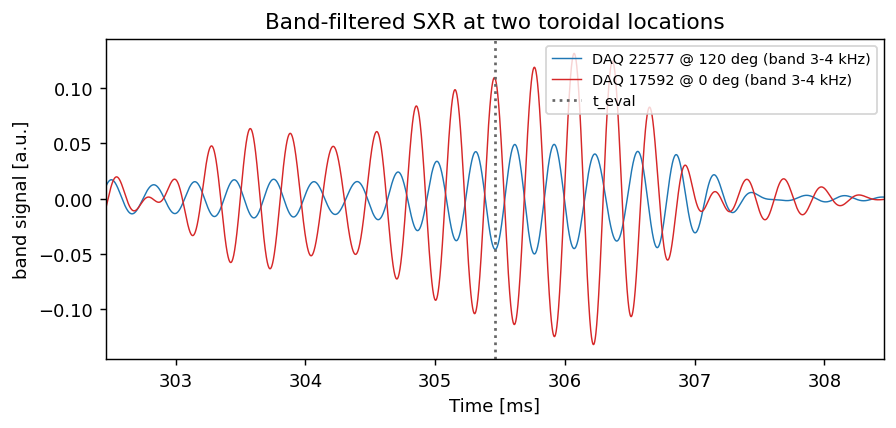

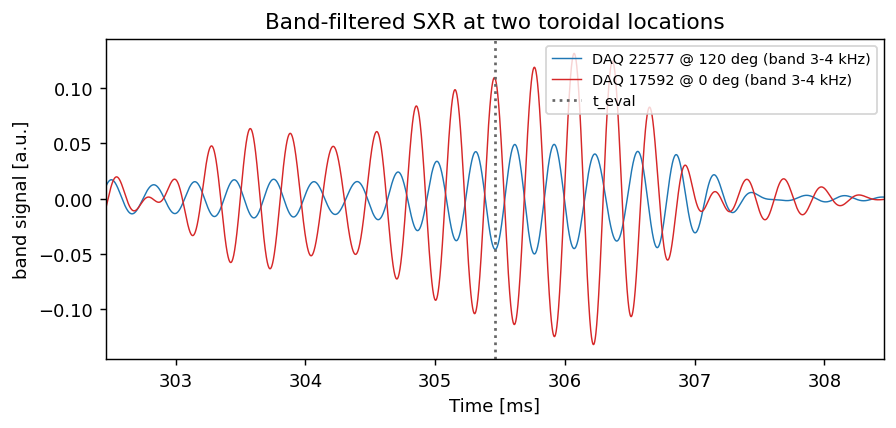

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for daq, color in (("22577", "tab:blue"), ("17592", "tab:red")):
    system = systems[daq]
    ax.plot(system["time"] * 1e3, system["signal"],
            color=color, lw=0.8,
            label=f"DAQ {daq} @ {system['theta']:.0f} deg (band {mode_band[0]/1e3:.0f}-{mode_band[1]/1e3:.0f} kHz)")
ax.axvline(t_eval * 1e3, color="0.4", ls=":", label="t_eval")
ax.set_xlim((t_eval - 0.003) * 1e3, (t_eval + 0.003) * 1e3)
ax.set_xlabel("Time [ms]"); ax.set_ylabel("band signal [a.u.]")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Band-filtered SXR at two toroidal locations")
fig.tight_layout()
fig.savefig(output_dir / "sxr_toroidal_mode_signals.png", dpi=200, bbox_inches="tight")
fig